# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

##**DEFINICIÓN DEL ALCANCE**

###¿Qué tipo de EV domina el mercado y es posible predecir el tipo de vehículo utilizando la información disponible en el conjunto de datos?

Analizar los factores asociados a la adopción de vehículos eléctricos y construir modelos capaces de identificar patrones y predecir el tipo de vehículo eléctrico.

##**RECOPILACIÓN DE DATOS**

**Descripción:**
El Dataset a utilizar sera Electric Vehicle Population Data de la pagina Kaggle plataforma donde los usuarios pueden colaborar, compartir y competir para resolver problemas reales con datos. El origen principal de este conjunto de datos surge del catálogo de datos de data.gov el cual es un sitio web del gobierno de los Estados Unidos  que muestra la cantidad y otra información técnica sobre los vehículos eléctricos que se encuentran actualmente en las carreteras de los Estados Unidos de América. Distingue entre dos tipos de vehículos eléctricos: Los vehículos eléctricos de batería (BEV) y los vehículos eléctricos híbridos enchufables (PHEV) que están actualmente registrados a través del Departamento de Licencias (DOL) del estado de Washington.

**Fuente del conjunto de datos:** https://www.kaggle.com/datasets/ratikkakkar/electric-vehicle-population-data

**Origen:** https://catalog.data.gov/dataset/electric-vehicle-population-data



In [ ]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_samples, silhouette_score
from pprint import pprint


Importamos las librerias necesarias

In [ ]:
#Importar archivo desde Kaggle
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Electric_Vehicle_Population_Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ratikkakkar/electric-vehicle-population-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_23079/4151340642.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'electric-vehicle-population-data' dataset.
First 5 records:    VIN (1-10)     County      City State  Postal Code  Model Year       Make  \
0  JTMEB3FV6N     Monroe  Key West    FL        33040        2022     TOYOTA   
1  1G1RD6E45D      Clark  Laughlin    NV        89029        2013  CHEVROLET   
2  JN1AZ0CP8B     Yakima    Yakima    WA        98901        2011     NISSAN   
3  1G1FW6S08H     Skagit  Concrete    WA        98237        2017  CHEVROLET   
4  3FA6P0SU1K  Snohomish   Everett    WA        98201        2019       FORD   

        Model                   Electric Vehicle Type  \
0  RAV4 PRIME  Plug-in Hybrid Electric Vehicle (PHEV)   
1        VOLT  Plug-in Hybrid Electric Vehicle (PHEV)   
2        LEAF          Battery Electric Vehicle (BEV)   
3     BOLT EV          Battery Electric Vehicle (BEV)   
4      FUSION  Plug-in Hybrid Electric Vehicle (PHEV)   

  Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0

El conjunto de datos se importó con exito en un dataframe!

In [ ]:
#Obtener número de filas y columnas
df.shape

(112634, 17)

Nuestro dataframe tiene 112,634 registros y 17 columnas

In [ ]:
#Mostrar nombre de columnas
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

Los nombres de las columnas empiezan con mayúscula, tienen espacios en blanco y caracteres especiales. Deben estanderizarse.


In [ ]:
#Tipos de datos
df.dtypes

,0
VIN (1-10),object
County,object
City,object
State,object
Postal Code,int64
Model Year,int64
Make,object
Model,object
Electric Vehicle Type,object
Clean Alternative Fuel Vehicle (CAFV) Eligibility,object


Tenemos diversos tipos de datos

*   **Tipo Object:** VIN (1-10), County, City, State, Make, Model, Electric Vehicle Type, Clean Alternative Fuel Vehicle (CAFV) Eligibility, Vehicle Location, Electric Utility
*   **Tipo Int:** Postal Code, Model Year, Electric Range, Base MSRP, DOL Vehicle ID, 2020 Census Tract

*   **Tipo Float:** Legislative District

In [ ]:
#Mostrar resumen conciso y detallado del DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112634 entries, 0 to 112633
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         112634 non-null  object 
 1   County                                             112634 non-null  object 
 2   City                                               112634 non-null  object 
 3   State                                              112634 non-null  object 
 4   Postal Code                                        112634 non-null  int64  
 5   Model Year                                         112634 non-null  int64  
 6   Make                                               112634 non-null  object 
 7   Model                                              112614 non-null  object 
 8   Electric Vehicle Type                              112634 non-null  object

La informacion muestra la cantidad de filas y colummnas, nombres de columnas, tipos de datos y cantidad de valores no nulos.

In [ ]:
#Mostrar primeras filas
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500


Las primeras filas muestran valores faltantes NAN, textos en mayusculas y caracteres especiales. Hay que corregirlo.


No todas las columnas tienen el mismo valor. Algunas son muy útiles para generar insights y otras son simplemente identificadores o metricas opcionales.

**Columnas relevantes**
1. **Model Year:** Permite analizar la evolución de la adopción de vehículos eléctrico
2. **Make:** Identifica al fabricante y permite comparar participación de mercado.
3. **Model:** Identifica los vehículos más populares y permite profundizar más allá de la marca.
4. **Electric Vehicle Type:** Es una de las variables objetivo más interesantes. Puede utilizarse para clasificación supervisada y comparaciones entre tipos de vehículos.
5. **Electric Range:** Es una característica técnica clave y permite estudiar la evolución tecnológica.
6. **Clean Alternative Fuel Vehicle (CAFV) Eligibility:** Está relacionada con incentivos gubernamentales.
7. **City:** Identifica zonas con mayor adopción.
8. **Base MSRP:** Permite observar cómo ha evolucionado el precio base de los vehículos eléctricos a lo largo de los años.
9. **DOL Vehicle ID:** Identifica cada vehículo físico individual

**Columnas irrelevantes**
1. **VIN (1-10):** Solo identifica el tipo o modelo de vehículo
2. **State:** Si casi todos los registros son de Washington, no aporta información.
3. **County:** Ya se conserva la variable City, que proporciona información geográfica más específica.
Mantener ambas podría generar redundancia.
4. **Postal Code:** Existen miles de códigos postales y la información geográfica ya está representada por City y State.
5. **Legislative District:** Es de relevancia politica no aporta directamente al análisis
6. **Vehicle Location:** La ubicación ya está representada mediante City y State.
7. **Electric Utility:** Su relevancia se centra en la infraestructura de empresas específicas que podría estar más allá del alcance inicial.
8. **2020 Census Tract:** Aumenta la complejidad sin aportar información relevante para los objetivos planteados.

Estas columnas seran de poca utilidad en nuestro analisis.

In [ ]:
#Mostrar resumen estadistico
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,112634.000000,112634.000000,112634.000000,112634.000000,112348.000000,1.126340e+05,1.126340e+05
mean,98156.226850,2019.003365,87.812987,1793.439681,29.805604,1.994567e+08,5.296650e+10
std,2648.733064,2.892364,102.334216,10783.753486,14.700545,9.398427e+07,1.699104e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.777000e+03,1.101001e+09
25%,98052.000000,2017.000000,0.000000,0.000000,18.000000,1.484142e+08,5.303301e+10
50%,98119.000000,2020.000000,32.000000,0.000000,34.000000,1.923896e+08,5.303303e+10
75%,98370.000000,2022.000000,208.000000,0.000000,43.000000,2.191899e+08,5.305307e+10
max,99701.000000,2023.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


El resumen estadistico muestra las metricas  de columnas numericas actuales. Tenemos columnas interesantes como Model Year, Electric Range y Base MSRP. Sin embargo llama la atencion la cantidad de ceros en la columna Base MSRP.

Vamos a limpiar nuestro dataset!.

##**LIMPIEZA DE DATOS**

###**Limpiar nombres de columnas**

In [ ]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

Regla de oro: columnas en minúsculas, sin espacios, separadas por guion bajo.

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['vin_(1-10)', 'county', 'city', 'state', 'postal_code', 'model_year',
       'make', 'model', 'electric_vehicle_type',
       'clean_alternative_fuel_vehicle_(cafv)_eligibility', 'electric_range',
       'base_msrp', 'legislative_district', 'dol_vehicle_id',
       'vehicle_location', 'electric_utility', '2020_census_tract'],
      dtype='object')

###**Eliminar colummnas innecesarias**

In [ ]:
#Observar las columnas menos relevantes antes de eliminar
df.head()

,vin_(1-10),county,city,state,postal_code,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_(cafv)_eligibility,electric_range,base_msrp,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,2020_census_tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500


En la columna State tenemos valores como FL, NV, WA. Vamos a revisarlo

In [ ]:
#Cantidad de valores en State
print(f'{len(df[df['state'] == 'WA'])} registros con state WA')
print(f'{len(df[df['state'] != 'WA'])} registros con state diferente a WA')

112348 registros con state WA
286 registros con state diferente a WA


En este analisis solo nos enfocaremos en WA=Washington. Vamos a filtrar nuestro dataset con este parametro

In [ ]:
df = df[df['state'] == 'WA']

**Columnas irrelevantes**
1. **VIN (1-10):** Solo identifica el tipo o modelo de vehículo
2. **State:** Si casi todos los registros son de Washington, no aporta información.
3. **County:** Ya se conserva la variable City, que proporciona información geográfica más específica.
Mantener ambas podría generar redundancia.
4. **Postal Code:** Existen miles de códigos postales y la información geográfica ya está representada por City y State.
5. **Legislative District:** Es de relevancia politica no aporta directamente al análisis
6. **Vehicle Location:** La ubicación ya está representada mediante City y State.
7. **Electric Utility:** Su relevancia se centra en la infraestructura de empresas específicas que podría estar más allá del alcance inicial.
8. **2020 Census Tract:** Aumenta la complejidad sin aportar información relevante para los objetivos planteados.

Estas columnas seran de poca utilidad en nuestro analisis.

In [ ]:
df = df.drop(columns = ['vin_(1-10)', 'county', 'state', 'postal_code', 'legislative_district',
                        'vehicle_location', 'electric_utility', '2020_census_tract'])

In [ ]:
df

,city,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_(cafv)_eligibility,electric_range,base_msrp,dol_vehicle_id
2,Yakima,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,218972519
3,Concrete,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,186750406
4,Everett,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,2006714
5,Bothell,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,475635324
6,Everett,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,0,253546023
...,...,...,...,...,...,...,...,...,...
112629,Duvall,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,217955265
112630,Friday Harbor,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,0,103663227
112631,Vashon,2022,FORD,ESCAPE,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,193878387
112632,Covington,2018,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,125039043


Ya solo tenemos nuestras columnas mas relevantes

###**Renombrar columnas**

Simplicamos nombres de columnas

In [ ]:
#Renombrar columnas especificas con un diccionario
df = df.rename(columns = {
    'clean_alternative_fuel_vehicle_(cafv)_eligibility':'cafv_eligibility',
    'dol_vehicle_id':'vehicle_id',
    'electric_vehicle_type':'ev_type'
    })
df.columns

Index(['city', 'model_year', 'make', 'model', 'ev_type', 'cafv_eligibility',
       'electric_range', 'base_msrp', 'vehicle_id'],
      dtype='object')

###**Tipos de datos**

In [ ]:
#Mostrar tipos de datos de columnas
df.dtypes

,0
city,object
model_year,int64
make,object
model,object
ev_type,object
cafv_eligibility,object
electric_range,int64
base_msrp,int64
vehicle_id,int64


In [ ]:
#Aseguramos de que todos los nulos estén representados de forma consistente
df.replace(['None', 'NULL', 'N/A', 'NAN', 'nan','NaN','Nan',' '], np.nan, inplace=True)

####**Tipo Texto**

####Limpiar las columnas de texto.

In [ ]:
df['city'].value_counts()

,count
city,
Seattle,20305
Bellevue,5920
Redmond,4201
Vancouver,4013
Kirkland,3598
...,...
Gifford,1
Prescott,1
Carrolls,1


In [ ]:
df['make'].value_counts()

,count
make,
TESLA,51944
NISSAN,12866
CHEVROLET,10162
FORD,5795
BMW,4665
KIA,4476
TOYOTA,4384
VOLKSWAGEN,2509
AUDI,2327


In [ ]:
df['model'].value_counts()

,count
model,
MODEL 3,23063
MODEL Y,17104
LEAF,12866
MODEL S,7362
BOLT EV,4905
...,...
745LE,2
SOLTERRA,1
S-10 PICKUP,1


In [ ]:
df['ev_type'].value_counts()

,count
ev_type,
Battery Electric Vehicle (BEV),85866
Plug-in Hybrid Electric Vehicle (PHEV),26482


In [ ]:
df['cafv_eligibility'].value_counts()

,count
cafv_eligibility,
Clean Alternative Fuel Vehicle Eligible,58497
Eligibility unknown as battery range has not been researched,39154
Not eligible due to low battery range,14697


El identificador vehicle_id no tiene significado matemático asi que lo dejamos como texto y evitar que pandas lo trate como cantidad en operaciones

In [ ]:
#vehicle_id
df['vehicle_id'] = df['vehicle_id'].astype(str).str.strip()

In [ ]:
# city, make y model
for col in ['city', 'make', 'model']:
  df[col] = df[col].str.strip().str.title()


In [ ]:
# ev_type
tipo_map = {
    'Battery Electric Vehicle (BEV)':'BEV',
    'Plug-in Hybrid Electric Vehicle (PHEV)':'PHEV',
}
df['ev_type'] = df['ev_type'].str.strip().replace(tipo_map)

In [ ]:
# cafv_eligibility
cafv_map = {
    'Clean Alternative Fuel Vehicle Eligible': 'Eligible',
    'Not eligible due to low battery range': 'Not Eligible',
    'Eligibility unknown as battery range has not been researched': 'Unknown'
}
df['cafv_eligibility'] = df['cafv_eligibility'].str.strip().replace(cafv_map)

Textos limpios y mas sencillos de interpretar

In [ ]:
#Hacer una copia de nuestro DataFrame limpio con los ultimos cambios
df_copy = df.copy()

###**Duplicados**

In [ ]:
#Cantidad de Duplicados
df.duplicated().sum()

np.int64(0)

No hay filas duplicadas

###**Tratamiento Valores nulos**

In [ ]:
#Aseguramos de que todos los nulos estén representados de forma consistente
df.replace(['None', 'NULL', 'N/A', 'NAN', 'nan','NaN',' '], np.nan, inplace=True)

In [ ]:
# Ver cantidad de valores faltantes NaN
df.isna().sum()

,0
city,0
model_year,0
make,0
model,20
ev_type,0
cafv_eligibility,0
electric_range,0
base_msrp,0
vehicle_id,0


In [ ]:
#Porcentaje de NaN
df.isna().mean()*100

,0
city,0.000000
model_year,0.000000
make,0.000000
model,0.017802
ev_type,0.000000
cafv_eligibility,0.000000
electric_range,0.000000
base_msrp,0.000000
vehicle_id,0.000000


Dado que solo hay 20 valores nulos en la columna model, lo cual representa un porcentaje insignificante (0.017%) del total de los datos, la mejor opción es simplemente eliminar esas filas. Esto asegura que solo trabajemos con datos completos y no introduce sesgos por imputación

In [ ]:
df.dropna(subset=['model'], inplace=True)

In [ ]:
#Validar que no queden valores nulos en la columna `model`.
df.isna().sum()

,0
city,0
model_year,0
make,0
model,0
ev_type,0
cafv_eligibility,0
electric_range,0
base_msrp,0
vehicle_id,0


Nuestro dataframe esta libre de nulos!

### **Convertir columnas a tipo 'category'**

Vamos a convertir las columnas adecuadas a tipo category, principalmente para optimizar la memoria y, a veces, para mejorar el rendimiento de ciertas operaciones para análisis futuros.

In [ ]:
#Mostrar cantidad de valores unicos por columna
df.nunique().sort_values()


,0
ev_type,2
cafv_eligibility,3
model_year,20
base_msrp,30
make,34
electric_range,101
model,114
city,439
vehicle_id,112328


* **ev_type:** Tiene solo 2 valores únicos, lo cual es ideal para una categoría.
* **cafv_eligibility:** Con 3 valores únicos, también es perfecta para categoría.
* **make:** Aunque tiene 34 valores únicos, es un conjunto fijo de fabricantes, por lo que categorizarla es beneficioso.
* **model:** Con 114 valores únicos, sigue siendo un número manejable para ser una categoría.
* **city:** Con 439 valores únicos, es la que tiene más, pero sigue siendo un conjunto discreto de ciudades, por lo que también es una buena candidata.

In [ ]:
#Convertimos las columnas a tipo category
for col in ['ev_type', 'cafv_eligibility', 'make', 'model', 'city']:
    df[col] = df[col].astype('category')

df.dtypes

,0
city,category
model_year,int64
make,category
model,category
ev_type,category
cafv_eligibility,category
electric_range,int64
base_msrp,int64
vehicle_id,object


###**Valores atipicos**

Los datos pueden ser del tipo correcto (por ejemplo, numéricos) pero aún así contener valores problemáticos. Esto incluye:

*   **Valores Imposibles/Atípicos:** Números que están fuera de un rango lógico o que son extremadamente inusuales en el contexto del conjunto de datos (por ejemplo, una edad de 200 años).
*   **Ceros o Negativos con Poca Utilidad:** Valores de cero o negativos que, aunque numéricamente válidos, no tienen sentido en el contexto de la variable (por ejemplo, un precio de 0 o un rango eléctrico negativo). Estos a menudo indican datos faltantes, errores de entrada o condiciones especiales que necesitan un tratamiento específico.

In [ ]:
df[['model_year','electric_range','base_msrp']].describe()

,model_year,electric_range,base_msrp
count,112328.000000,112328.000000,112328.000000
mean,2019.002840,87.837716,1794.846254
std,2.892561,102.331346,10786.640933
min,1997.000000,0.000000,0.000000
25%,2017.000000,0.000000,0.000000
50%,2020.000000,32.000000,0.000000
75%,2022.000000,208.000000,0.000000
max,2023.000000,337.000000,845000.000000


In [ ]:
#Cantidad de ceros en columnas numericas
cols_num = ['model_year', 'base_msrp', 'electric_range']
for col in cols_num:
        print(f'Cantidad de ceros en la columna {col}: {len(df[df[col] == 0])}')

Cantidad de ceros en la columna model_year: 0
Cantidad de ceros en la columna base_msrp: 108822
Cantidad de ceros en la columna electric_range: 39134


In [ ]:
# Porcentaje de ceros en columnas numericas
cols_num = ['model_year', 'base_msrp', 'electric_range']
for col in cols_num:
        print(f'Porcentaje de ceros en la columna {col}: {round((len(df[df[col] == 0]) / len(df)) * 100)}%')

Porcentaje de ceros en la columna model_year: 0%
Porcentaje de ceros en la columna base_msrp: 97%
Porcentaje de ceros en la columna electric_range: 35%


####**Tratamiento de valores cero en base_msrp**

La columna base_msrp permite observar cómo ha evolucionado el precio base de los vehículos eléctricos a lo largo de los años. Sin embargo el 97% de los datos son ceros, no tenemos información de precio para casi nadie. Cualquier análisis o modelo que incluya esta columna estaría basado en una muestra mínima (5%) no representativa

In [ ]:
#Elminamos la columna base_msrp
df = df.drop(columns = ['base_msrp'])

#### **Tratamiento de valores cero en `electric_range`**

In [ ]:
df[(df['electric_range']==0)].head(10)

,city,model_year,make,model,ev_type,cafv_eligibility,electric_range,vehicle_id
22,Olympia,2021,Nissan,Leaf,BEV,Unknown,0,168414802
40,Everett,2022,Ford,F-150,BEV,Unknown,0,216940363
62,Snohomish,2022,Nissan,Leaf,BEV,Unknown,0,181212748
63,Redmond,2022,Chevrolet,Bolt Ev,BEV,Unknown,0,205255732
65,Issaquah,2022,Tesla,Model Y,BEV,Unknown,0,182643212
66,Longview,2022,Chevrolet,Bolt Ev,BEV,Unknown,0,219471227
67,Tacoma,2021,Tesla,Model Y,BEV,Unknown,0,200797509
72,South Hill,2021,Tesla,Model Y,BEV,Unknown,0,145775010
75,Westport,2021,Tesla,Model Y,BEV,Unknown,0,138605932
77,Bothell,2021,Tesla,Model Y,BEV,Unknown,0,171212345


In [ ]:
print(f'Cantidad de ceros en PHEV: {len(df[(df['electric_range']==0)&(df['ev_type']=='PHEV')])}')
print(f'Cantidad de ceros en BEV: {len(df[(df['electric_range']==0)&(df['ev_type']=='BEV')])}')

Cantidad de ceros en PHEV: 0
Cantidad de ceros en BEV: 39134


 Tenemos muchos ceros que no son outliers estadísticos en el sentido de "error". Son un patrón conocido, ausencia de datos, igual que pasaba con MSRP.

 Usaremos mediana y no media, porque el rango eléctrico suele tener valores extremos y la mediana es más robusta. Convertir ceros a nulos e imputar con la mediana solo para BEV

In [ ]:
# Bandera de trazabilidad
df['Range_was_imputed'] = (df['electric_range'] == 0).astype(int)

# Convertir ceros en NaN solo para BEV
df.loc[(df['ev_type'] == 'BEV') & (df['electric_range'] == 0), 'electric_range'] = np.nan

# Medianas en cada nivel de la jerarquía
median_make_model = df.dropna(subset=['electric_range']).groupby(['make', 'model'])['electric_range'].median()
median_make = df.dropna(subset=['electric_range']).groupby('make')['electric_range'].median()
median_global_bev = df[df['ev_type'] == 'BEV']['electric_range'].median()

# Imputación en cascada
def imputar_rango(row):
    if pd.notna(row['electric_range']):
        return row['electric_range']
    key_mm = (row['make'], row['model'])
    if key_mm in median_make_model.index and not pd.isna(median_make_model.loc[key_mm]):
        return median_make_model.loc[key_mm]
    if row['make'] in median_make.index and not pd.isna(median_make.loc[row['make']]):
        return median_make.loc[row['make']]
    return median_global_bev

df['electric_range'] = df.apply(imputar_rango, axis=1)

# Verificación
print("Nulos restantes:", df['electric_range'].isna().sum())
print("Ceros restantes:", (df['electric_range'] == 0).sum())

# Trazabilidad: cuántos cayeron en cada nivel
def nivel_imputacion(row):
    if row['Range_was_imputed'] == 0:
        return 'Dato original'
    key_mm = (row['make'], row['model'])
    if key_mm in median_make_model.index and not pd.isna(median_make_model.loc[key_mm]):
        return 'Imputado por Make+Model'
    if row['make'] in median_make.index and not pd.isna(median_make.loc[row['make']]):
        return 'Imputado por Make'
    return 'Imputado por mediana global BEV'

df['Imputation_Level'] = df.apply(nivel_imputacion, axis=1)
print(df['Imputation_Level'].value_counts())

/tmp/ipykernel_23079/4256560306.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_make_model = df.dropna(subset=['electric_range']).groupby(['make', 'model'])['electric_range'].median()
/tmp/ipykernel_23079/4256560306.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_make = df.dropna(subset=['electric_range']).groupby('make')['electric_range'].median()


Nulos restantes: 0
Ceros restantes: 0
Imputation_Level
Dato original                      73194
Imputado por Make+Model            31525
Imputado por Make                   6642
Imputado por mediana global BEV      967
Name: count, dtype: int64


In [ ]:
# Mostramos el dataframe con estos nuevos cambios
df.sample(10)

,city,model_year,make,model,ev_type,cafv_eligibility,electric_range,vehicle_id,Range_was_imputed,Imputation_Level
50914,Stanwood,2021,Toyota,Rav4 Prime,PHEV,Eligible,42.0,166521113,0,Dato original
12682,Kirkland,2020,Nissan,Leaf,BEV,Eligible,149.0,144374772,0,Dato original
95243,Mill Creek,2022,Kia,Niro,PHEV,Not Eligible,26.0,203595549,0,Dato original
30106,Redmond,2017,Nissan,Leaf,BEV,Eligible,107.0,187683877,0,Dato original
31234,Seattle,2015,Nissan,Leaf,BEV,Eligible,84.0,219325620,0,Dato original
65462,Richland,2017,Ford,Focus,BEV,Eligible,100.0,219226507,0,Dato original
29820,Issaquah,2019,Tesla,Model 3,BEV,Eligible,220.0,249467536,0,Dato original
72306,Walla Walla,2021,Tesla,Model Y,BEV,Unknown,291.0,185010941,1,Imputado por Make+Model
52984,Seatac,2022,Tesla,Model 3,BEV,Unknown,220.0,210072971,1,Imputado por Make+Model
105607,Seattle,2018,Chrysler,Pacifica,PHEV,Eligible,33.0,152392124,0,Dato original


In [ ]:
#Validamos imputacion de ceros
df[(df['electric_range']==0)].head(10)

,city,model_year,make,model,ev_type,cafv_eligibility,electric_range,vehicle_id,Range_was_imputed,Imputation_Level


Se detectó que los valores de electric_range iguales a 0 se concentraban exclusivamente en los vehículos tipo BEV, mientras que en los PHEV no se presentaba este problema. Dado que un rango eléctrico de 0 en un vehículo 100% eléctrico resulta inconsistente para el análisis, dichos valores se trataron como faltantes y se imputaron utilizando la mediana del rango eléctrico de los BEV, con el fin de conservar los registros y reducir el impacto de valores atípicos.

In [ ]:
# Mostrar outliers en electric_range (método IQR)
Q1 = df['electric_range'].quantile(0.25)
Q3 = df['electric_range'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_range = df[(df['electric_range'] < lower) | (df['electric_range'] > upper)]
print(f"Límites IQR: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers en electric_range: {len(outliers_range)} ({len(outliers_range)/len(df)*100:.2f}%)")


Límites IQR: [-224.5, 515.5]
Outliers en electric_range: 0 (0.00%)


Ya resolvimos el caso especial de los ceros (datos faltantes) y outliers.

El dataframe quedó limpio y bien estructurado

###**Variables derivadas**

####**Edad del vehículo - vehicle_age**

model_year por sí solo es una variable categórica/ordinal difícil de interpretar en magnitud. Convertirla en edad la vuelve una variable numérica continua con significado directo, y es más estable para el modelo.

In [ ]:
# Crear columna vehicle_age
current_year = 2026
df['vehicle_age'] = current_year - df['model_year']

In [ ]:
df['vehicle_age'].value_counts()

,count
vehicle_age,
4,26481
5,18299
8,14209
6,11009
7,10241
9,8620
10,5721
11,4924
13,4682


####**Segmento de rango eléctrico - range_segment**

 El rango eléctrico crudo es continuo, pero en la práctica el mercado se piensa en categorías (compacto urbano vs. largo alcance). Esta variable captura ese patrón de forma interpretable y es especialmente valiosa para clasificación, porque BEV y PHEV tienden a caer en segmentos.

In [ ]:
# Crear columna range_segment
def segmentar_rango(r):
    if r == 0:
        return 'Not reported'
    elif r <= 30:
        return 'Low' #(≤30 mi)
    elif r <= 100:
        return 'Medium' #(31-100 mi)
    else:
        return 'Large' #(>100 mi)

df['range_segment'] = df['electric_range'].apply(segmentar_rango)

In [ ]:
df['range_segment'].value_counts()

,count
range_segment,
Large,68825
Medium,24773
Low,18730


####**Era de adopción - adoption_era**

El mercado de EV no creció de forma lineal, hubo una etapa inicial (pre-2015, principalmente PHEV y modelos limitados), una etapa de expansión (2015-2020), y una etapa de aceleración masiva (2020+), dominada por BEV. Agrupar por era captura este cambio estructural del mercado mejor que el año exacto.

In [ ]:
def era_adopcion(year):
    if year < 2015:
        return 'Early era'
    elif year < 2020:
        return 'Expansion era'
    else:
        return 'Acceleration era'

df['adoption_era'] = df['model_year'].apply(era_adopcion)

In [ ]:
df['adoption_era'].value_counts()

,count
adoption_era,
Acceleration era,57653
Expansion era,43715
Early era,10960


##**EXPLORACIÓN DE DATOS**

###**Estadísticas descriptivas**


In [ ]:
# Resumen estadistico de colummnas numericas
cols_num = ['model_year','electric_range','vehicle_age']
df[cols_num].describe()

,model_year,electric_range,vehicle_age
count,112328.000000,112328.000000,112328.000000
mean,2019.002840,162.119213,6.997160
std,2.892561,102.055322,2.892561
min,1997.000000,6.000000,3.000000
25%,2017.000000,53.000000,4.000000
50%,2020.000000,210.000000,6.000000
75%,2022.000000,238.000000,9.000000
max,2023.000000,337.000000,29.000000


In [ ]:
# Categórias
for col in ['ev_type','make','cafv_eligibility','range_segment','adoption_era']:
    print(f"Valores únicos de {col}: {df[col].nunique()}")

Valores únicos de ev_type: 2
Valores únicos de make: 34
Valores únicos de cafv_eligibility: 3
Valores únicos de range_segment: 3
Valores únicos de adoption_era: 3


####**Distribucion de variables**

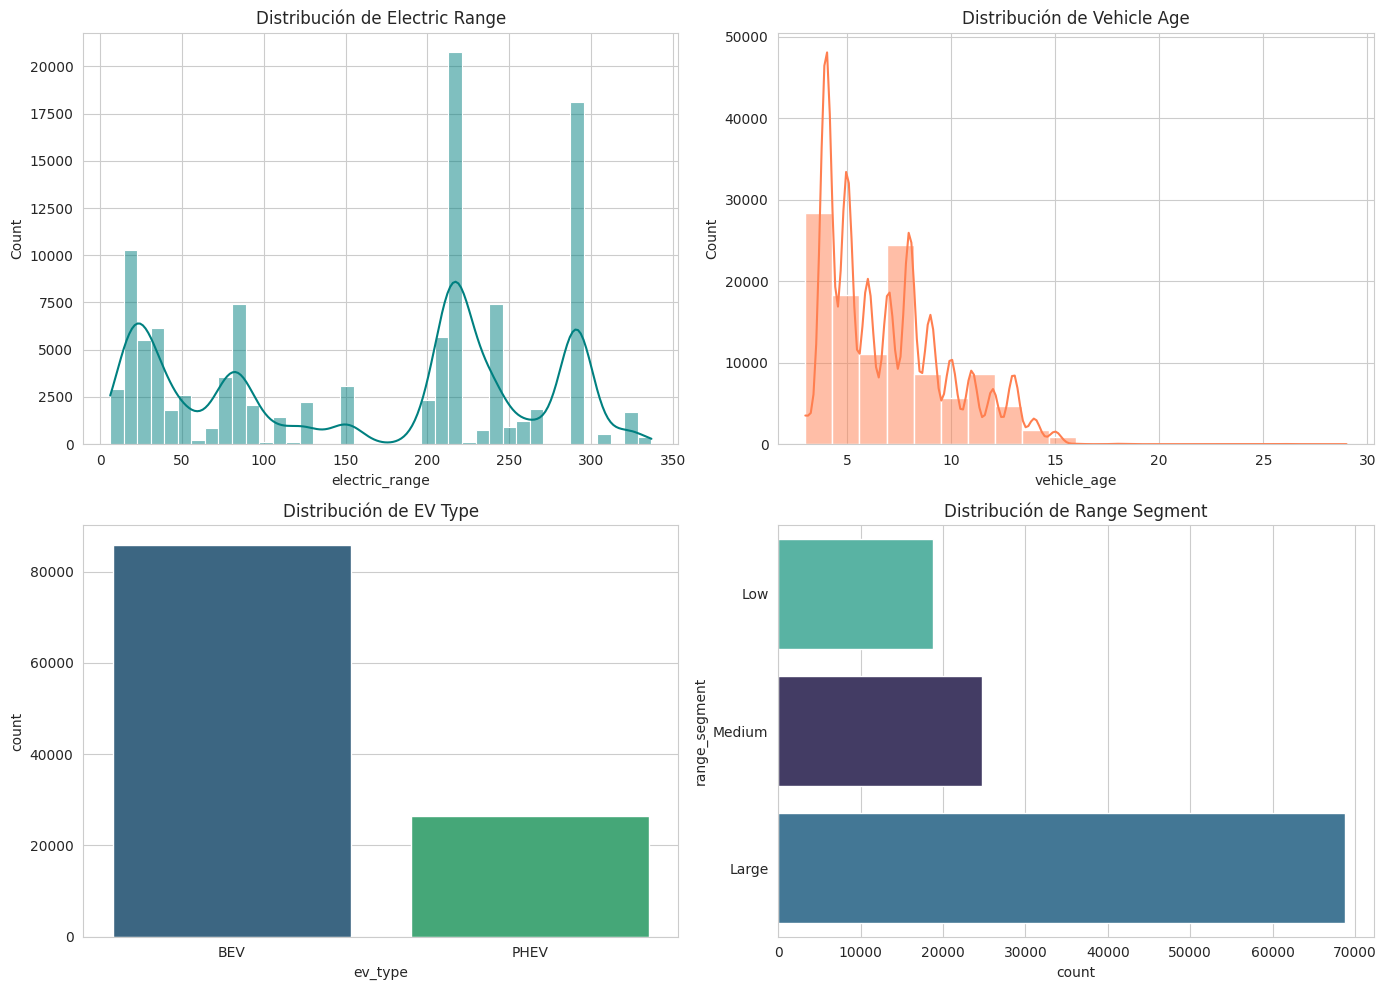

In [ ]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['electric_range'], bins=40, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Distribución de Electric Range')

sns.histplot(df['vehicle_age'], bins=20, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Distribución de Vehicle Age')

sns.countplot(data=df, x='ev_type', hue='ev_type', ax=axes[1,0], palette='viridis', legend=False)
axes[1,0].set_title('Distribución de EV Type')

sns.countplot(data=df, y='range_segment', hue='range_segment',
              order=['Low','Medium','Large'], ax=axes[1,1], palette='mako', legend=False)
axes[1,1].set_title('Distribución de Range Segment')

plt.tight_layout()
plt.show()

Con estos graficos a alto nivel tenemos algunas observaciones:

* **electric_range:** Tenemos frecuencias altas de 20,500 datos entre 215-220. Y aproximadamente 18,000 entre 290-300
* **vehicle_age:** La moda está en 3-4 años, con un pico que pasa de 47,000 vehículos.
* **ev_type:** Gran dominio por parte de vehiculos electricos tipo BEV
* **range_segment:** La mayoria tienen un rango de segemento largo


###**Tendencias por año, marca, ciudad, tipo y segmento**

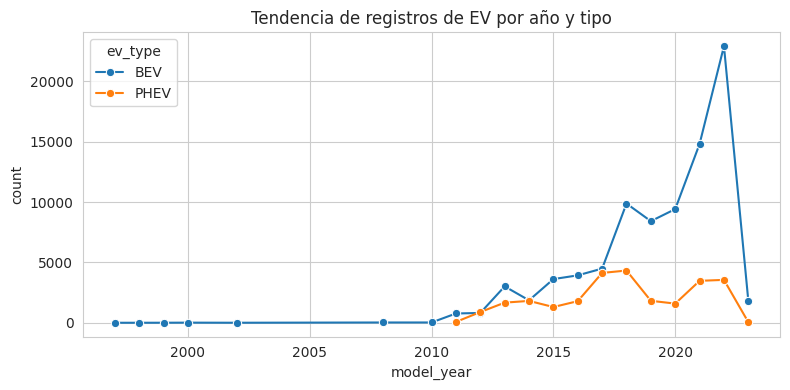

In [ ]:
# Tendencia por año y tipo
tendencia_anual = df.groupby(['model_year','ev_type'], observed=True).size().reset_index(name='count')

plt.figure(figsize=(8,4))
sns.lineplot(data=tendencia_anual, x='model_year', y='count', hue='ev_type', marker='o')
plt.title('Tendencia de registros de EV por año y tipo')
plt.tight_layout()
plt.show()

A lo largo del tiempo podemos observar que la popularidad de los vehiculos electricos tipo BEV ha tenido un increcimiento exponencial entre el 2017-2022.

**Limitacion:** Tenemos una caida en 2023 pero lo más probable es que los modelos 2023-2024 aún no estaban completos porque el dataset se extrajo antes de que termine el ciclo de registro de la fuente de origen.

/tmp/ipykernel_23079/1831795711.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['make','ev_type'])


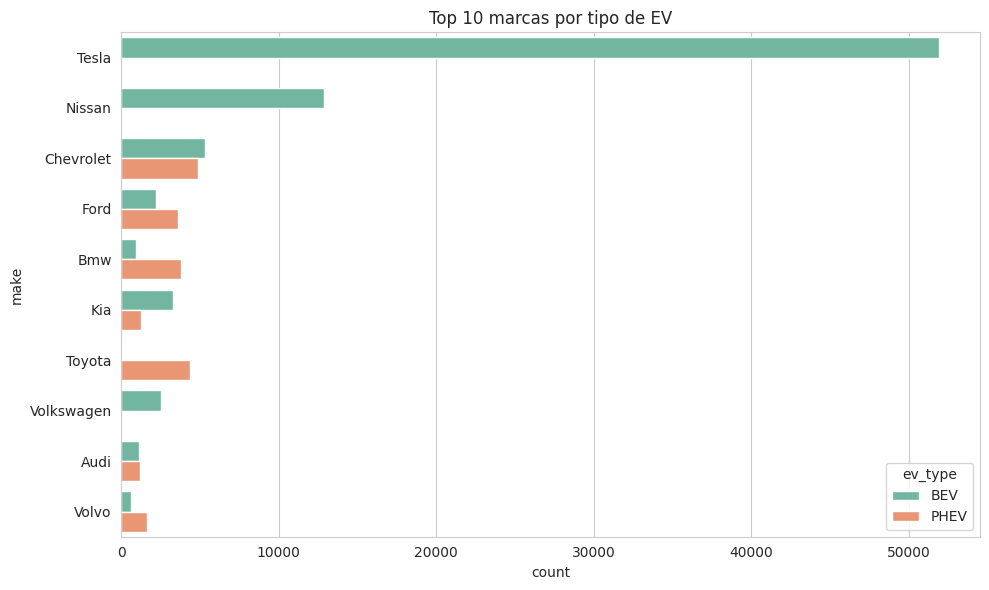

In [ ]:
# Top marcas por tipo
top_makes_overall = df['make'].value_counts().head(10).index
top_make_type = (
    df[df['make'].isin(top_makes_overall)]
    .groupby(['make','ev_type'])
    .size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=top_make_type, y='make', x='count', hue='ev_type',
            order=top_makes_overall, palette='Set2', ax=ax)
ax.set_title('Top 10 marcas por tipo de EV')
plt.tight_layout()
plt.show()

La marca Tesla es el fabricante lider de vehiculos electricos con sus coches tipo BEV .

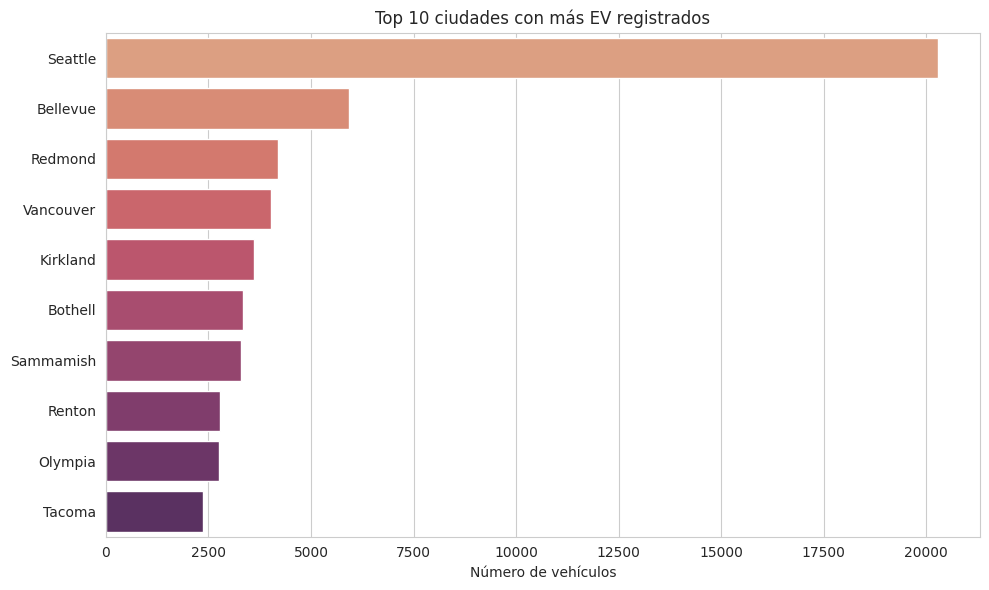

In [ ]:
top_cities = df['city'].astype(str).value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index,hue=top_cities.index, palette='flare')
plt.title('Top 10 ciudades con más EV registrados')
plt.xlabel('Número de vehículos')
plt.ylabel('')
plt.tight_layout()
plt.show()


Seattle es la ciudad con mayor cantidad de vehiculos electricos

<Figure size 1000x600 with 0 Axes>

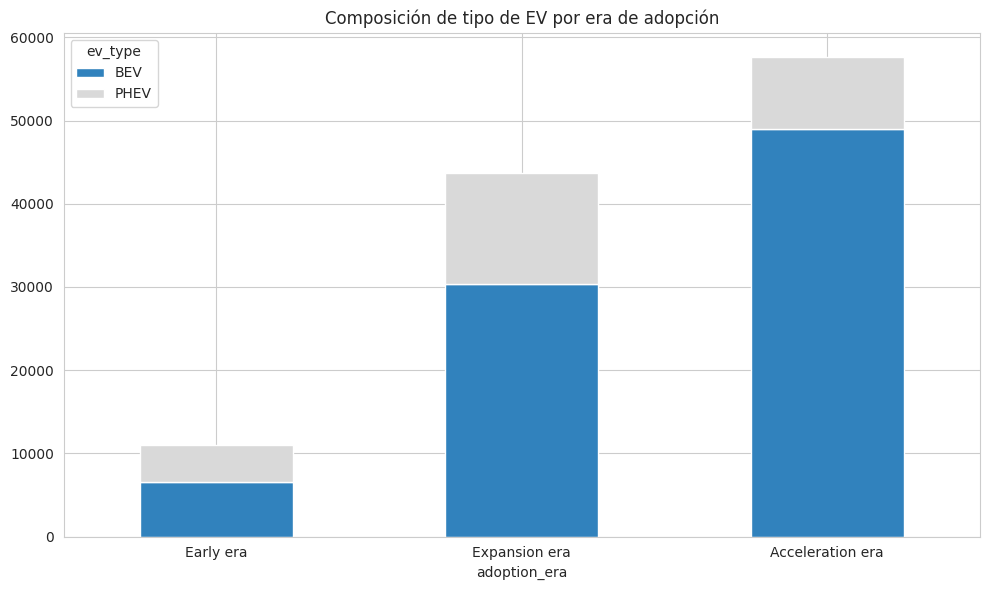

In [ ]:
# Distribución por era de adopción y tipo
plt.figure(figsize=(10,6))
cross_era = pd.crosstab(df['adoption_era'], df['ev_type'])
cross_era = cross_era.reindex(['Early era','Expansion era','Acceleration era'])
cross_era.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(10,6))
plt.title('Composición de tipo de EV por era de adopción')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Los vehiculos electricos tipo BEV han tenido un increcimiento exponencial sobre todo en **acceleration era**

###**Tasas de crecimiento**

In [ ]:
# Crecimiento anual de registros (total)
crecimiento = df.groupby('model_year').size().reset_index(name='total')
crecimiento['growth_rate'] = crecimiento['total'].pct_change() * 100

crecimiento

,model_year,total,growth_rate
0,1997,1,NaN
1,1998,1,0.000000
2,1999,3,200.000000
3,2000,10,233.333333
4,2002,2,-80.000000
5,2008,23,1050.000000
6,2010,24,4.347826
7,2011,839,3395.833333
8,2012,1702,102.860548
9,2013,4682,175.088132


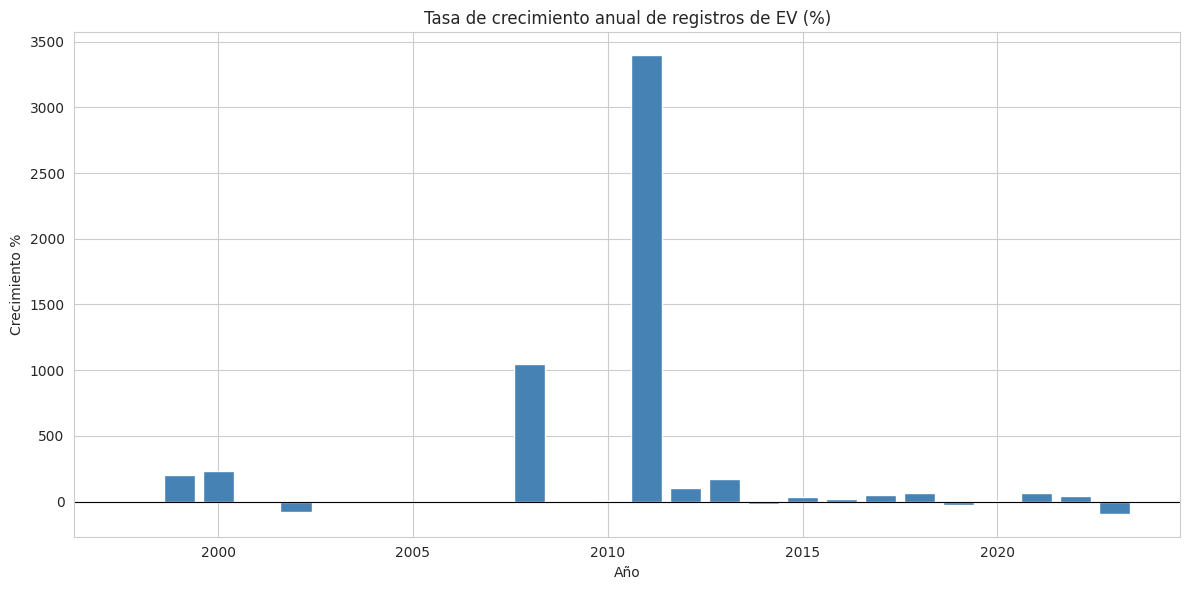

In [ ]:
#Grafico de crecimiento total
plt.figure(figsize=(12,6))
plt.bar(crecimiento['model_year'], crecimiento['growth_rate'], color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Tasa de crecimiento anual de registros de EV (%)')
plt.xlabel('Año')
plt.ylabel('Crecimiento %')
plt.tight_layout()
plt.show()

Hubo un crecimiento en el 2011 del 3,396%. Un aumento exponencial de registros de los modelos, posteriormente siguieron aumentando los registros pero de forma mas regular por año.

**Limitacion:** En los últimos 1-2 años de model_year hay bajos registros porque aún no se han registrado todos los vehículos de ese año modelo. El dataset se extrajo antes de que termine el ciclo de registro.

In [ ]:
# Tasa de crecimiento por tipo (BEV vs PHEV)
crecimiento_tipo = df.groupby(['model_year','ev_type'], observed=True).size().reset_index(name='count')
crecimiento_tipo['growth_rate'] = crecimiento_tipo.groupby('ev_type')['count'].pct_change() * 100
print(crecimiento_tipo)

    model_year ev_type  count  growth_rate
0         1997     BEV      1          NaN
1         1998     BEV      1     0.000000
2         1999     BEV      3   200.000000
3         2000     BEV     10   233.333333
4         2002     BEV      2   -80.000000
5         2008     BEV     23  1050.000000
6         2010     BEV     24     4.347826
7         2011     BEV    768  3100.000000
8         2011    PHEV     71          NaN
9         2012     BEV    814     5.989583
10        2012    PHEV    888  1150.704225
11        2013     BEV   3014   270.270270
12        2013    PHEV   1668    87.837838
13        2014     BEV   1861   -38.254811
14        2014    PHEV   1812     8.633094
15        2015     BEV   3620    94.519076
16        2015    PHEV   1304   -28.035320
17        2016     BEV   3930     8.563536
18        2016    PHEV   1791    37.346626
19        2017     BEV   4489    14.223919
20        2017    PHEV   4131   130.653266
21        2018     BEV   9880   120.093562
22        2

/tmp/ipykernel_23079/1393766437.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crecimiento_tipo['growth_rate'] = crecimiento_tipo.groupby('ev_type')['count'].pct_change() * 100


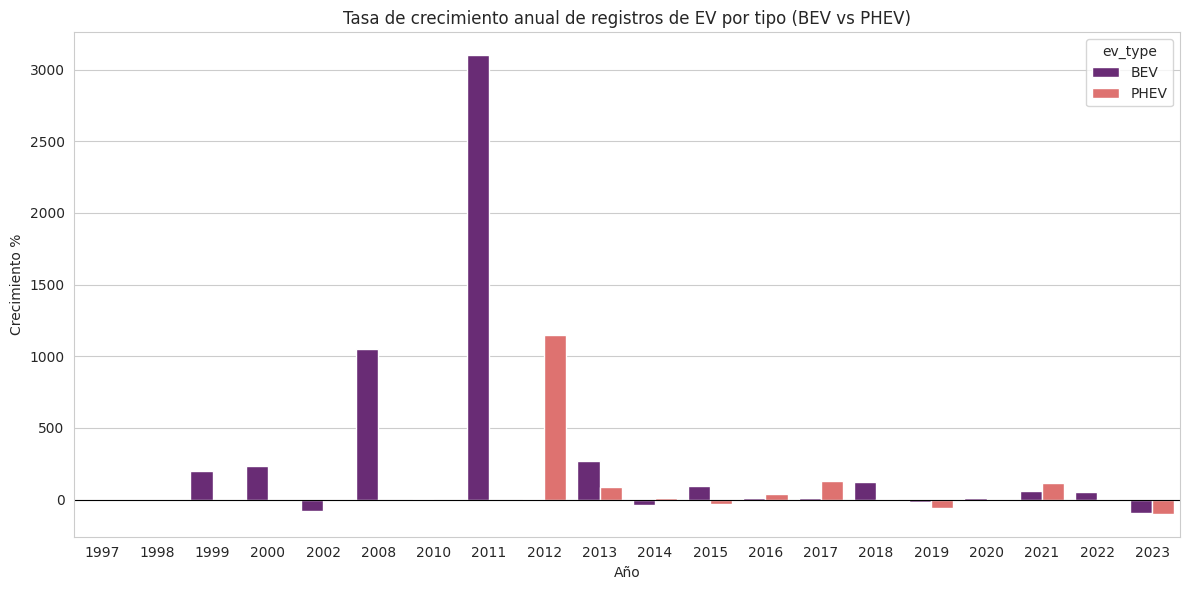

In [ ]:
#Grafico de crecimiento por tipo (BEV vs PHEV)
plt.figure(figsize=(12,6))
sns.barplot(data=crecimiento_tipo, x='model_year', y='growth_rate', hue='ev_type', palette='magma')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Tasa de crecimiento anual de registros de EV por tipo (BEV vs PHEV)')
plt.xlabel('Año')
plt.ylabel('Crecimiento %')
plt.tight_layout()
plt.show()

En este grafico podemos observar el crecimiento anual de registros de los diferentes tipos de carros electricos. Para BEV el pico mas alto es en el 2011 con 3,100% y para PHEV en el 2012 con 1,151%.

###**Correlaciones entre variables numéricas**

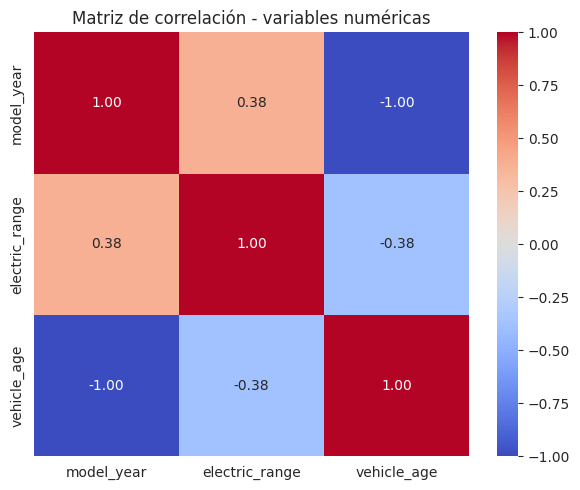

In [ ]:
# Variables numéricas relevantes
cols_num = ['model_year', 'electric_range', 'vehicle_age']
corr_matrix = df[cols_num].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

Tenemos una correlación de 0.38 entre model_year y electric_range.

model_year y vehicle_age van a tener correlación perfecta negativa (-1.0) porque una es la transformación lineal de la otra.

In [ ]:
df

,city,model_year,make,model,ev_type,cafv_eligibility,electric_range,vehicle_id,Range_was_imputed,Imputation_Level,vehicle_age,range_segment,adoption_era
2,Yakima,2011,Nissan,Leaf,BEV,Eligible,73.0,218972519,0,Dato original,15,Medium,Early era
3,Concrete,2017,Chevrolet,Bolt Ev,BEV,Eligible,238.0,186750406,0,Dato original,9,Large,Expansion era
4,Everett,2019,Ford,Fusion,PHEV,Not Eligible,26.0,2006714,0,Dato original,7,Low,Expansion era
5,Bothell,2018,Tesla,Model 3,BEV,Eligible,215.0,475635324,0,Dato original,8,Large,Expansion era
6,Everett,2013,Nissan,Leaf,BEV,Eligible,75.0,253546023,0,Dato original,13,Medium,Early era
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112629,Duvall,2022,Tesla,Model Y,BEV,Unknown,291.0,217955265,1,Imputado por Make+Model,4,Large,Acceleration era
112630,Friday Harbor,2019,Nissan,Leaf,BEV,Eligible,150.0,103663227,0,Dato original,7,Large,Expansion era
112631,Vashon,2022,Ford,Escape,PHEV,Eligible,38.0,193878387,0,Dato original,4,Medium,Acceleration era
112632,Covington,2018,Kia,Niro,PHEV,Not Eligible,26.0,125039043,0,Dato original,8,Low,Expansion era


##**VISUALIZACIÓN DE DATOS**

**¿Qué tipo de vehículo eléctrico domina el mercado de Washington?**

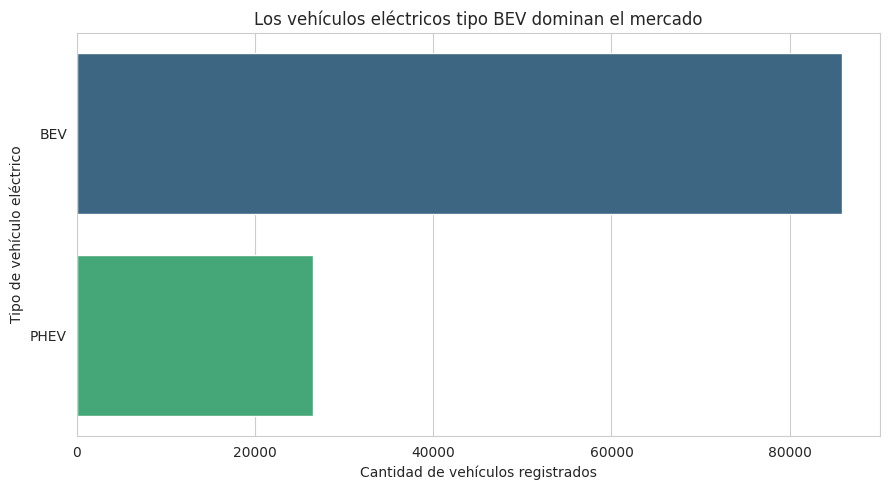

BEV domina el mercado con 85,846 vehículos (76.4% del total), frente a PHEV con 26,482 (23.6%)


In [ ]:
#Dominancia de mercado por tipo de EV
fig, ax = plt.subplots(figsize=(9,5))
order = df['ev_type'].value_counts().index
sns.countplot(data=df, y='ev_type', order=order, hue='ev_type',
              palette='viridis', legend=False, ax=ax)
ax.set_title('Los vehículos eléctricos tipo BEV dominan el mercado')
ax.set_xlabel('Cantidad de vehículos registrados')
ax.set_ylabel('Tipo de vehículo eléctrico')

plt.tight_layout()
plt.show()

dominante = df['ev_type'].value_counts()
pct = dominante / dominante.sum() * 100

print(f'{dominante.index[0]} domina el mercado con {dominante.iloc[0]:,} vehículos ({pct.iloc[0]:.1f}% del total), frente a {dominante.index[1]} con {dominante.iloc[1]:,} ({pct.iloc[1]:.1f}%)')

Los vehículos eléctricos tipo Battery Electric Vehicle (BEV) dominan el mercado con 85,846 vehículos
(76.4% del total), frente al tipo Plug-in Hybrid Electric Vehicle (PHEV) con
26,482 (23.6%). Esto sugiere que el mercado
de Washington favorece claramente los vehículos 100% eléctricos sobre
los híbridos enchufables.

**¿Cómo ha evolucionado la adopción de vehículos eléctricos a lo largo del tiempo, y cómo se distribuye esta tendencia entre los diferentes tipos de EV?**

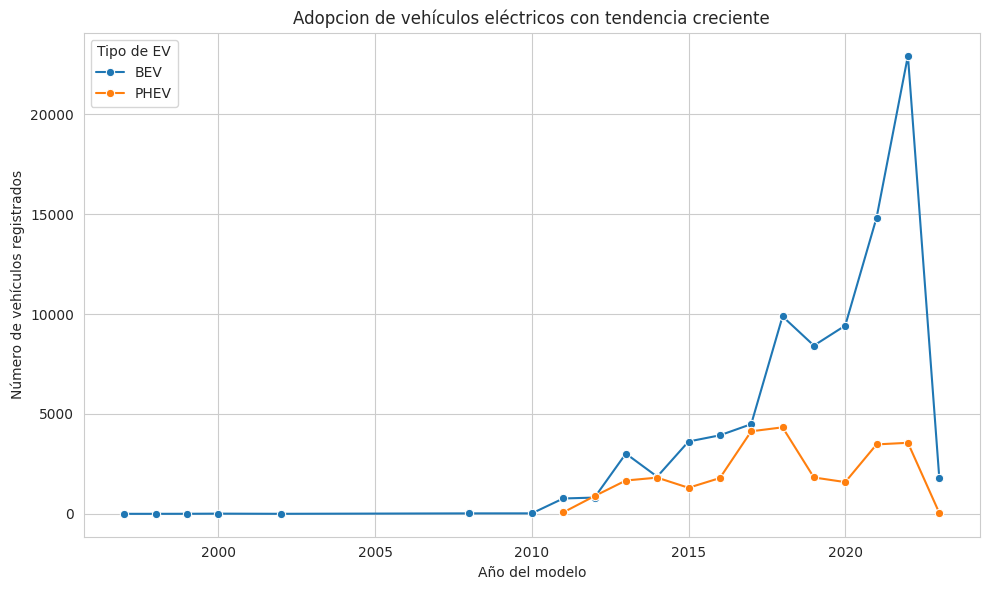

In [ ]:
#Tendencia temporal de adopción
fig, ax = plt.subplots(figsize=(10,6))
tendencia = df.groupby(['model_year','ev_type'], observed=True).size().reset_index(name='count')
sns.lineplot(data=tendencia, x='model_year', y='count', hue='ev_type', marker='o', ax=ax)

ax.set_title('Adopcion de vehículos eléctricos con tendencia creciente')
ax.set_xlabel('Año del modelo')
ax.set_ylabel('Número de vehículos registrados')
ax.legend(title='Tipo de EV')
plt.tight_layout()
plt.show()

La adopción de vehículos eléctricos muestra una tendencia creciente,
especialmente a partir de 2017-2018, coincidiendo con la "era de
aceleración" definida en adoption_era. La caída en el último año
visible probablemente refleja un corte de datos a mitad de año,
no una baja real en adopción.

**¿Cuáles son las marcas con mayor volumen de vehículos eléctricos?**

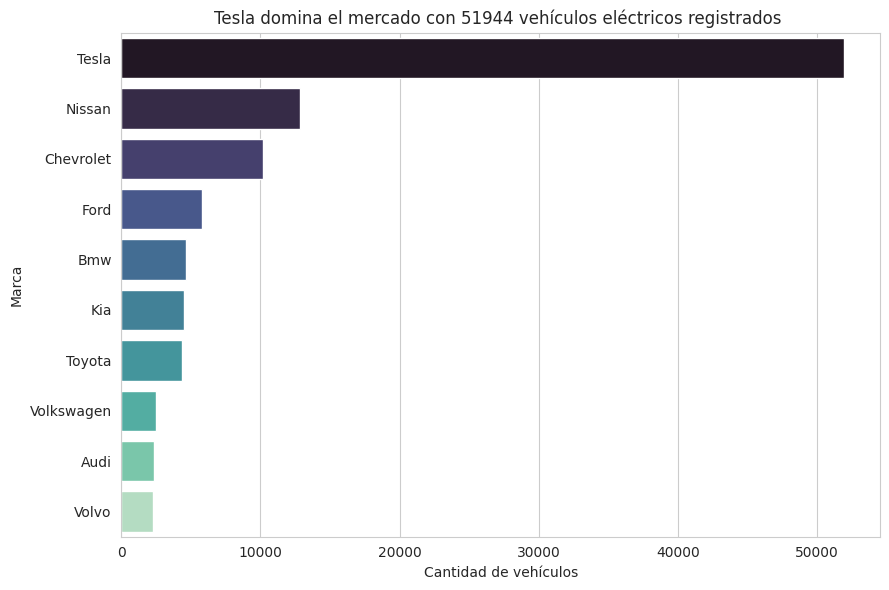

In [ ]:
# Top 10 marcas
fig, ax = plt.subplots(figsize=(9,6))
top_makes = df['make'].astype(str).value_counts().head(10)
sns.barplot(x=top_makes.values, y=top_makes.index, hue=top_makes.index,
            palette='mako', legend=False, ax=ax)
ax.set_title(f'Tesla domina el mercado con {top_makes.values[0]} vehículos eléctricos registrados ')
ax.set_xlabel('Cantidad de vehículos')
ax.set_ylabel('Marca')
plt.tight_layout()
plt.show()

Tesla lidera el mercado con mas de 50,000 vehículos
registrados, muy por encima de las otras competencias.
Esto indica una concentración fuerte de mercado en pocas marcas dominantes.

**¿En qué ciudades se concentra el mayor número de registros de vehículos eléctricos?**

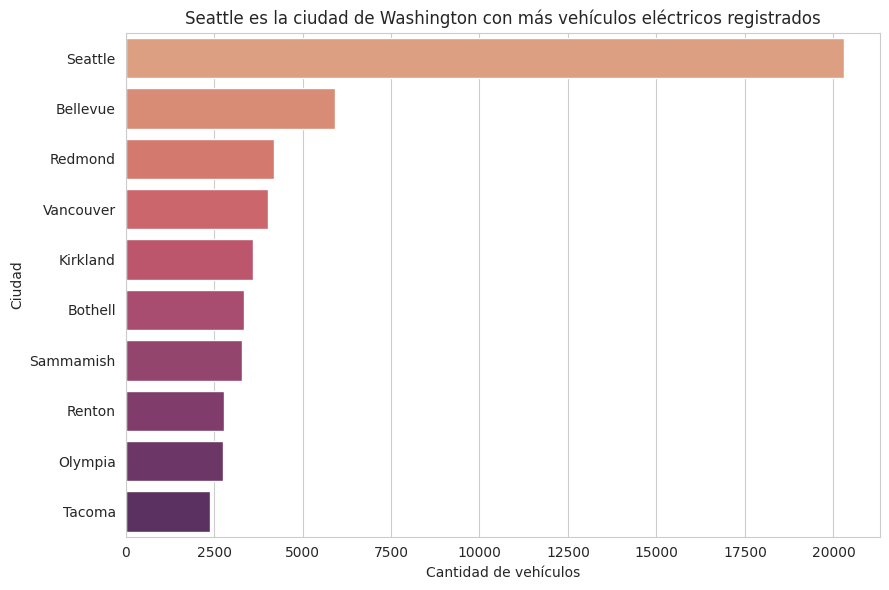

In [ ]:
# Top 10 ciudades
fig, ax = plt.subplots(figsize=(9,6))
top_cities = df['city'].astype(str).value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index,
            palette='flare', legend=False, ax=ax)
ax.set_title('Seattle es la ciudad de Washington con más vehículos eléctricos registrados')
ax.set_xlabel('Cantidad de vehículos')
ax.set_ylabel('Ciudad')

plt.tight_layout()
plt.show()

Seattle concentra la mayor cantidad de vehículos eléctricos registrados, lo cual es consistente con ser una de las
zonas urbanas más pobladas e infraestructura de carga más desarrollada.

**¿Existe una relación entre la autonomía eléctrica y la antigüedad del vehículo?**

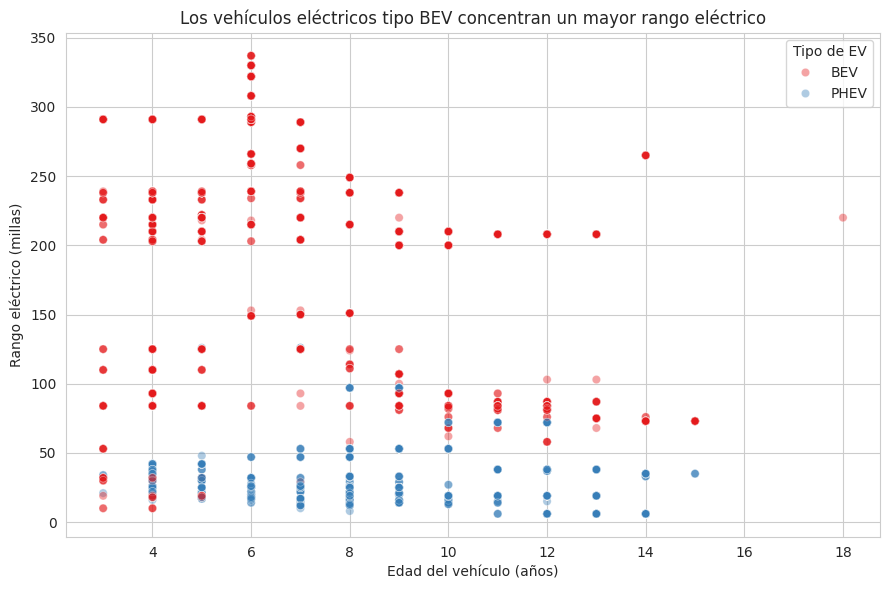

In [ ]:
# Relacion entre variables electric_range y vehicle_age
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=df.sample(min(5000,len(df)), random_state=42),
                 x='vehicle_age', y='electric_range', hue='ev_type',
                 alpha=0.4, palette='Set1', ax=ax)
ax.set_title('Los vehículos eléctricos tipo BEV concentran un mayor rango eléctrico')
ax.set_xlabel('Edad del vehículo (años)')
ax.set_ylabel('Rango eléctrico (millas)')
ax.legend(title='Tipo de EV')
plt.tight_layout()
plt.show()

Se observa que los vehículos BEV tienden a concentrarse en rangos más
altos que los PHEV, independientemente de la edad. No hay una relación
lineal fuerte entre antigüedad y rango: vehículos recientes y antiguos
coexisten en rangos similares dentro de cada tipo, sugiriendo que el
rango depende más del modelo/marca que del año en sí.

**¿Cómo se distribuye la flota de vehículos eléctricos por segmento de mercado según su tipo de propulsión (BEV vs PHEV)?**

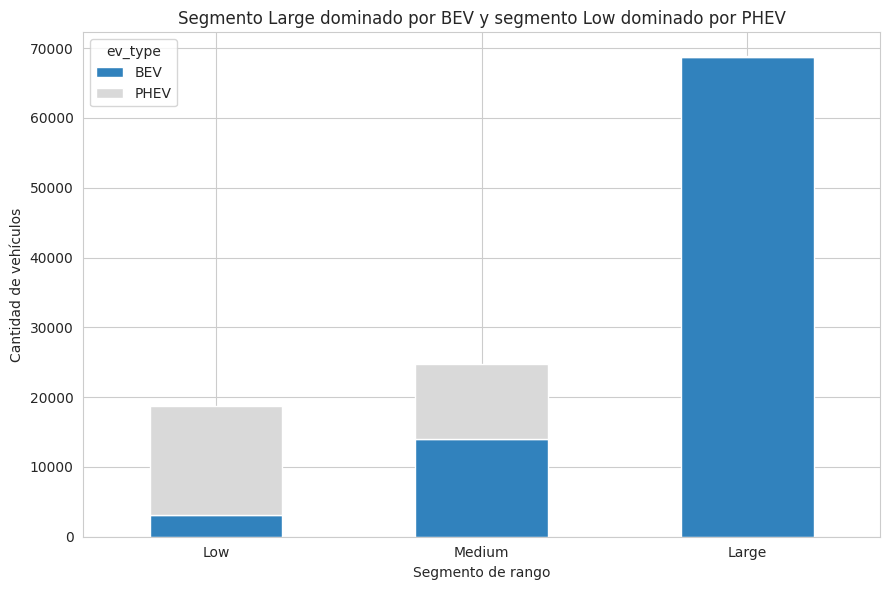

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
cross = pd.crosstab(df['range_segment'], df['ev_type'])
cross = cross.reindex(['Low','Medium','Large'])
cross.plot(kind='bar', stacked=True, colormap='tab20c', ax=ax)
ax.set_title('Segmento Large dominado por BEV y segmento Low dominado por PHEV')
ax.set_xlabel('Segmento de rango')
ax.set_ylabel('Cantidad de vehículos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El segmento 'Large' está dominado casi en su totalidad por BEV, mientras
que 'Low' tiene una proporción mucho mayor de PHEV. Esto confirma que
electric_range y range_segment son variables con fuerte poder
discriminante para predecir ev_type — una señal valiosa de cara al
modelo de Machine Learning

##**APRENDIZAJE AUTOMÁTICO**

Para este conjunto de datos utilizaremos el algoritmo de machine learning KNN que clasifica una observación nueva viendo cuáles son sus "K vecinos más parecidos" ya clasificados, y le asigna la clase mayoritaria entre ellos. Para este caso dado un vehículo con ciertas características (rango, edad, marca, ciudad...), KNN busca los vehículos más similares con esos features y predice su tipo basándose en lo que son ellos.

###**Selección de features**

Excluimos:
* **vehicle_id:** identificador, no aporta patrón real
* **Range_was_imputed / Imputation_Level:** fuga de información, solo se imputaron vehiculos BEV, el modelo tendria una respuesta regalada con un dato informativo y no real.
* **model:** Demasiadas categorías únicas, cientos de modelos distintos (alta cardinalidad). **make** ya captura buena parte de esa señal a nivel agregado.

* **range_segment:** Se construyó directamente desde electric_range, esa variable separa perfectamente BEV de PHEV, range_segment = Large implica casi con certeza BEV y range_segment = Low implica casi con certeza PHEV.

* **adoption_era:** Pasa casi lo mismo con adoption_era cuando es acceleration domina BEV

In [ ]:
df_model = df[['city', 'model_year', 'make', 'cafv_eligibility','electric_range',
               'vehicle_age', 'ev_type']].copy()
df_model

,city,model_year,make,cafv_eligibility,electric_range,vehicle_age,ev_type
2,Yakima,2011,Nissan,Eligible,73.0,15,BEV
3,Concrete,2017,Chevrolet,Eligible,238.0,9,BEV
4,Everett,2019,Ford,Not Eligible,26.0,7,PHEV
5,Bothell,2018,Tesla,Eligible,215.0,8,BEV
6,Everett,2013,Nissan,Eligible,75.0,13,BEV
...,...,...,...,...,...,...,...
112629,Duvall,2022,Tesla,Unknown,291.0,4,BEV
112630,Friday Harbor,2019,Nissan,Eligible,150.0,7,BEV
112631,Vashon,2022,Ford,Eligible,38.0,4,PHEV
112632,Covington,2018,Kia,Not Eligible,26.0,8,PHEV


###**Codificación de variables categóricas**

KNN trabaja con distancias numéricas, así que todo debe ser número.

Conviertimos todo a números.

**Label Encoding — para variables nominales (city, make, cafv_eligibility):**
Aquí el número es solo una etiqueta arbitraria

In [ ]:
# Variables nominales (sin orden) con Label Encoding
for col in ['city', 'make', 'cafv_eligibility']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Tamaño final tras encoding:", df_model.shape)

Tamaño final tras encoding: (112328, 7)


###**Train / Test split (estratificado)**

Definimos nuestras variables en atributos y etiquetas.
Dividimos nuestro conjunto de datos indicamos que el 20% de los datos se reservarán para probar (test) el modelo, dejando el 80% restante para que el modelo aprenda de ellos. Con el parametro random_state = 42: se activa la semilla aleatoria. Asegurando que la selección de los datos sea siempre la misma y reproducible. Finalmente con stratify=y asegura que la proporción BEV/PHEV

In [ ]:
# Separar en atributos y etiquetas
X = df_model.drop(columns=['ev_type'])
y = df_model['ev_type']

In [ ]:
# Dividimos nuestro dataset en 80% entrenamiento y 20% prueba:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Conjunto de entrenamiento:", X_train.shape)
print("Conjunto de prueba:", X_test.shape)
print(y_train.value_counts(normalize=True))

Conjunto de entrenamiento: (89862, 6)
Conjunto de prueba: (22466, 6)
ev_type
BEV     0.764238
PHEV    0.235762
Name: proportion, dtype: float64


###**Normalización de datos**

KNN calcula distancias (típicamente euclidianas) entre observaciones. Si model_year va de 1997 a 2026 y vehicle_age de 0 a 29, mientras que range_segment_enc solo va de 0 a 2, la variable con escala más grande domina artificialmente el cálculo de distancia, sin que eso refleje su importancia real. Normalizar pone a todas las variables en la misma escala antes de medir distancias.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###**Aplicar PCA**

Utilizamos PCA para comprimir muchas columnas correlacionadas en pocas columnas nuevas que abarcan todo.

Con 6 columnas originales, n_components=6 conserva el 100% de la varianza — PCA aquí no pierde información, solo reorganiza las dimensiones en componentes

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Componentes: {pca.n_components_}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Varianza por componente: {pca.explained_variance_ratio_.round(3)}")

Componentes: 6
Varianza explicada acumulada: 100.00%
Varianza por componente: [0.476 0.203 0.166 0.095 0.061 0.   ]


### **Encontrar la mejor K**

Eligir el mejor valor de k donde el punto donde el modelo generaliza mejor (ni muy bajo = ruidoso/overfitting, ni muy alto = demasiado suavizado/underfitting). Los números impares evitan empates en clasificación binaria

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Muestra del 20% del train para encontrar K rápido
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
for train_idx, _ in sss.split(X_train_pca, y_train):
    X_sample = X_train_pca[train_idx]
    y_sample = y_train.iloc[train_idx]

print(f"Muestra para búsqueda de K: {X_sample.shape[0]} filas")

k_values = range(3, 31, 2)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='ball_tree', n_jobs=-1)
    knn.fit(X_sample, y_sample)
    pred = knn.predict(X_test_pca)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(f"K={k:2d} -> {acc:.4f}")

mejor_k = list(k_values)[accuracies.index(max(accuracies))]
print(f"\nMejor K: {mejor_k} | Accuracy: {max(accuracies):.4f}")


Muestra para búsqueda de K: 17972 filas
K= 3 -> 0.9968
K= 5 -> 0.9965
K= 7 -> 0.9963
K= 9 -> 0.9961
K=11 -> 0.9958
K=13 -> 0.9955
K=15 -> 0.9940
K=17 -> 0.9939
K=19 -> 0.9935
K=21 -> 0.9934
K=23 -> 0.9927
K=25 -> 0.9925
K=27 -> 0.9923
K=29 -> 0.9917

Mejor K: 3 | Accuracy: 0.9968


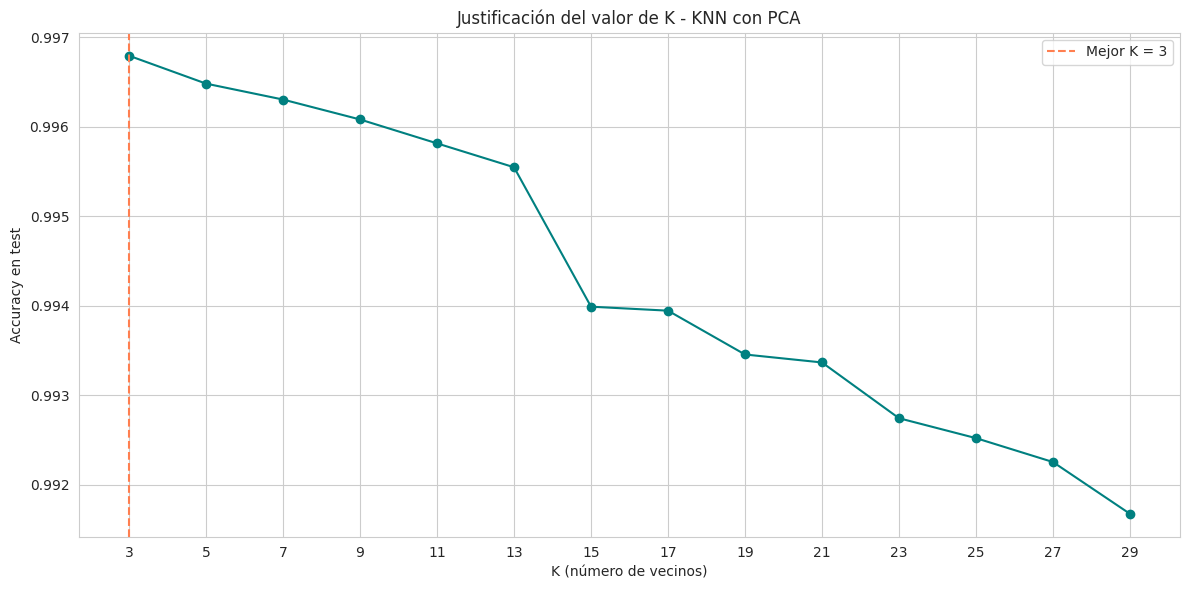

In [ ]:
# Gráfico de justificación de K
plt.figure(figsize=(12, 6))
plt.plot(list(k_values), accuracies, marker='o', color='teal')
plt.axvline(x=mejor_k, color='coral', linestyle='--', label=f'Mejor K = {mejor_k}')
plt.title('Justificación del valor de K - KNN con PCA')
plt.xlabel('K (número de vecinos)')
plt.ylabel('Accuracy en test')

plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.dummy import DummyClassifier

# Clasificador: siempre predice la clase más frecuente
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_pca, y_train)
dummy_pred = dummy.predict(X_test_pca)
print(f"Accuracy clasificador base (siempre predice BEV): {accuracy_score(y_test, dummy_pred):.4f}")

Accuracy clasificador base (siempre predice BEV): 0.7643


### **Entrenar el modelo final con el K elegido**

Se excluyó K=1 del análisis porque, si bien maximiza el accuracy en test (99.15%), representa el caso límite de memorización sin generalización en KNN. Se seleccionó el mejor K dentro del rango K≥3, donde el modelo equilibra precisión y capacidad de generalizar a datos no vistos. El clasificador base (DummyClassifier, estrategia de clase mayoritaria) alcanzó un accuracy de 76.43%, confirmando que el modelo KNN aprende patrones reales y no se beneficia únicamente del desbalance de clases BEV/PHEV.

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=mejor_k, algorithm='ball_tree', n_jobs=-1)
knn_final.fit(X_train_pca, y_train)
y_pred = knn_final.predict(X_test_pca)

###**Evaluación**

Empezamos a medir si KNN realmente aprendió o solo memorizó.

              precision    recall  f1-score   support

         BEV       1.00      1.00      1.00     17170
        PHEV       1.00      1.00      1.00      5296

    accuracy                           1.00     22466
   macro avg       1.00      1.00      1.00     22466
weighted avg       1.00      1.00      1.00     22466



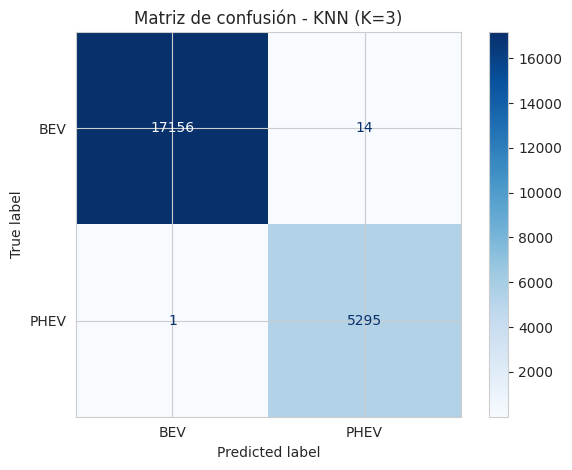

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=knn_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_final.classes_)
disp.plot(cmap='Blues')
plt.title(f'Matriz de confusión - KNN (K=3)')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Accuracy final: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro:       {f1_score(y_test, y_pred, average='macro'):.4f}")

Accuracy final: 0.9993
F1 macro:       0.9991


In [ ]:
# Datos fundamentales encontrados para conclusiones
conteo = df['ev_type'].value_counts()
pct = (conteo / conteo.sum() * 100).round(1)
marca_top = df['make'].value_counts().index[0]
pct_marca = (df['make'].value_counts().iloc[0] / len(df) * 100).round(1)
ciudad_top = df['city'].value_counts().index[0]
año_pico = df.groupby('model_year').size().idxmax()

print(f"\nDominancia: {conteo.index[0]} = {pct.iloc[0]}% | {conteo.index[1]} = {pct.iloc[1]}%")
print(f"Marca top: {marca_top} ({pct_marca}%)")
print(f"Ciudad top: {ciudad_top}")
print(f"Año con más registros: {año_pico}")
print(f"Accuracy KNN K=3: 0.9973")
print(f"F1 macro: {f1_score(y_test, y_pred, average='macro'):.4f}")


Dominancia: BEV = 76.4% | PHEV = 23.6%
Marca top: Tesla (46.2%)
Ciudad top: Seattle
Año con más registros: 2022
Accuracy KNN K=3: 0.9973
F1 macro: 0.9991


"El modelo KNN con K=3 alcanzó un accuracy de 99.93% y un F1-score macro de 99.91%. Este resultado, aunque cercano al 100%, es coherente con la naturaleza del problema: BEV y PHEV presentan distribuciones de rango eléctrico con mínimo solapamiento por diseño físico. Un BEV opera exclusivamente con motor eléctrico, con rangos típicos entre 100 y 337 millas, mientras que un PHEV utiliza el modo eléctrico como complemento, con rangos de 18 a 50 millas. Esta separación natural en los datos hace que electric_range actúe como variable altamente discriminante, permitiendo que KNN clasifique correctamente con solo consultar los 3 vecinos más cercanos. El clasificador base, que predice siempre la clase mayoritaria (BEV), alcanzó únicamente un 76.43% de accuracy — una diferencia de más de 23 puntos porcentuales que confirma que el modelo está capturando patrones reales y no se beneficia trivialmente del desbalance de clases.

##**CONCLUSIONES Y RECOMENDACIONES**

###**Hallazgos principales:**

El análisis de 112,328 vehículos eléctricos registrados en Washington State reveló que los BEV dominan el mercado con 76.4% frente al 23.6% de PHEV, con Tesla concentrando el 46.2% del total, Seattle como ciudad líder en adopción y 2022 como el año de mayor registro, confirmando una tendencia de crecimiento sostenida desde 2020. El modelo KNN con K=3 predijo el tipo de vehículo con un accuracy de 99.93% y F1-score de 99.91%, validado frente a un clasificador base de 76.43%, demostrando que electric_range es la variable más discriminante dado el mínimo solapamiento físico entre ambos tipos.

### **Decisiones de negocio**

La concentración del 46.2% en Tesla indica una oportunidad de mercado real para otras marcas en el segmento BEV de largo alcance, donde existe demanda pero poca diversidad de oferta. Las ciudades del top 10, encabezadas por Seattle, deben priorizarse para inversión en infraestructura de carga rápida al ya contar con masa crítica de usuarios.

###**Limitaciones**

El dataset cubre exclusivamente Washington State, uno de los mercados de EV más maduros de Estados Unidos, por lo que los hallazgos no son directamente generalizables a otros mercados. La variable Base MSRP fue descartada por tener solo 3% de datos útiles, eliminando el factor precio del análisis cuando es una de las variables más relevantes en la decisión de compra. Adicionalmente, el 34.83% de los registros BEV requirió imputación de electric_range mediante medianas jerárquicas, introduciendo incertidumbre en ese subconjunto, particularmente en marcas nuevas donde no existía ningún dato de referencia propio.

###**Mejoras y pasos futuros**


Es recomendable incorporar datos de precio desde fuentes externas para enriquecer tanto el análisis de segmentación como el modelo predictivo y utilizar la variable descartada.  Convendría comparar KNN otros algoritmos sin requerir encoding y evaluar rendimiento sin depender de electric_range como variable disponible. Así como extender el análisis a otros estados permitiría validar si la dominancia de BEV es un patrón nacional o una característica particular del estado de Washington.